# GNN-BERT for Understanding Context from Music
### CSE425 - Neural Networks Project


###Impots

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, average_precision_score, mean_absolute_error, r2_score

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


#Loading the datasets

In [ ]:
import zipfile

zip_files=['/content/fma_metadata.zip', '/content/DEAM_Annotations.zip', '/content/DEAM_audio.zip']
extract_path = '/content/dataset'

for file in zip_files:
  with zipfile.ZipFile(file, 'r') as zip_ref:
      zip_ref.extractall(extract_path)

print("Datasets extracted successfully!")

Datasets extracted successfully!


In [ ]:
import os
import glob
import pandas as pd
import librosa


N_TRACKS = 220
N_SEGMENTS = 8          # segments per track
FEAT_DIM = 16           # pretend chroma/mfcc feature size
CAPTION_LEN = 6         # words per caption

USE_DEAM_PRIMARY = True  # flip to True once DEAM is downloaded - this is now the main dataset
USE_REAL_DATA = False     # legacy MagnaTagATune path, kept in case you want it back later
USE_FMA = True           # flip to True once fma_small + fma_metadata are downloaded (Task 4)
USE_MUSICCAPS = True     # flip to True once MusicCaps audio has been pulled (Task 4)


DEAM_ANNOTATIONS = [
    '/content/dataset/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv',
    '/content/dataset/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv',
]
DEAM_AUDIO_DIR = '/content/dataset/MEMD_audio'

FMA_METADATA = '/content/dataset/fma_metadata/tracks.csv'
FMA_AUDIO_DIR = '/content/dataset/fma_metadata'


MUSICCAPS_CSV = '/content/musiccaps-public.csv'
MUSICCAPS_AUDIO_DIR = '/content/musiccaps_audio'

N_SEGMENTS_REAL = N_SEGMENTS
CHROMA_BINS = 12
CLIP_DURATION = 29.0


def segment_chroma(y, sr, n_segments=N_SEGMENTS_REAL):
    # chroma features over the whole clip, then average within N equal windows
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=CHROMA_BINS)
    n_frames = chroma.shape[1]
    bounds = np.linspace(0, n_frames, n_segments + 1).astype(int)
    feats = []
    for i in range(n_segments):
        seg = chroma[:, bounds[i]:bounds[i + 1]]
        if seg.shape[1] == 0:
            seg = chroma[:, -1:]
        feats.append(seg.mean(axis=1))
    feats = np.stack(feats).astype(np.float32)
    # pad/trim so it matches FEAT_DIM (16) - chroma is only 12 bins, so pad zeros
    if feats.shape[1] < FEAT_DIM:
        pad = np.zeros((feats.shape[0], FEAT_DIM - feats.shape[1]), dtype=np.float32)
        feats = np.concatenate([feats, pad], axis=1)
    return feats


def build_adj_from_feats(feats, sim_thresh=0.8):
    n = feats.shape[0]
    adj = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        if i > 0:
            adj[i, i - 1] = 1
            adj[i - 1, i] = 1
    norm = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    sim = norm @ norm.T
    adj[sim > sim_thresh] = 1
    np.fill_diagonal(adj, 1)
    return adj


In [ ]:
QUADRANTS = ['happy_energetic', 'calm_content', 'sad_depressed', 'angry_tense']
QUADRANT_WORDS = {
    'happy_energetic': 'happy energetic',
    'calm_content': 'calm content',
    'sad_depressed': 'sad depressed',
    'angry_tense': 'angry tense',
}


def valence_arousal_to_quadrant(valence, arousal):
    if valence >= 0.5 and arousal >= 0.5:
        return 'happy_energetic'
    if valence >= 0.5 and arousal < 0.5:
        return 'calm_content'
    if valence < 0.5 and arousal < 0.5:
        return 'sad_depressed'
    return 'angry_tense'

In [ ]:
def load_deam(annotations_csvs, audio_dir, sr=22050, clip_duration=45.0):

    if isinstance(annotations_csvs, str):
        annotations_csvs = [annotations_csvs]
    ann = pd.concat([pd.read_csv(p) for p in annotations_csvs], ignore_index=True)
    ann.columns = [c.strip() for c in ann.columns]
    tracks = []
    for _, row in ann.iterrows():
        song_id = int(row['song_id'])
        path = os.path.join(audio_dir, str(song_id) + '.mp3')
        if not os.path.exists(path):
            continue
        try:
            y, _ = librosa.load(path, sr=sr, duration=clip_duration)
        except Exception:
            continue
        feats = segment_chroma(y, sr)
        adj = build_adj_from_feats(feats)

        valence = (row['valence_mean'] - 1) / 8.0
        arousal = (row['arousal_mean'] - 1) / 8.0
        quadrant = valence_arousal_to_quadrant(valence, arousal)
        yvec = np.array([1.0 if q == quadrant else 0.0 for q in QUADRANTS], dtype=np.float32)
        tracks.append({
            'feats': feats, 'adj': adj, 'genre': quadrant,
            'caption': QUADRANT_WORDS[quadrant], 'y': yvec,
            'valence': float(valence), 'arousal': float(arousal),
        })
    return tracks

if USE_DEAM_PRIMARY:
    dataset = load_deam(DEAM_ANNOTATIONS, DEAM_AUDIO_DIR)
    N_LABELS = len(QUADRANTS)
    TEXT_VOCAB = ['happy', 'energetic', 'calm', 'content', 'sad', 'depressed', 'angry', 'tense']
    random.shuffle(dataset)
    n_train = int(0.8 * len(dataset))
    train_set, test_set = dataset[:n_train], dataset[n_train:]
    print(f'loaded {len(dataset)} DEAM tracks {N_LABELS} mood-quadrant tags')

loaded 1802 DEAM tracks 4 mood-quadrant tags


In [ ]:
def load_fma(metadata_csv, audio_dir, subset='small', n_tracks=400, sr=22050, clip_duration=29.0):
    # tracks.csv has a 2-row header (top-level + sub-level column names)
    tracks_df = pd.read_csv(metadata_csv, index_col=0, header=[0, 1])
    subset_mask = tracks_df[('set', 'subset')] == subset
    tracks_df = tracks_df[subset_mask]
    tracks_df = tracks_df.sample(n=min(n_tracks, len(tracks_df)), random_state=SEED)

    out = []
    for track_id, row in tracks_df.iterrows():
        genre = row[('track', 'genre_top')]
        if not isinstance(genre, str) or genre == '':
            continue
        tid_str = '{:06d}'.format(track_id)
        path = os.path.join(audio_dir, tid_str[:3], tid_str + '.mp3')
        if not os.path.exists(path):
            continue
        try:
            y, _ = librosa.load(path, sr=sr, duration=clip_duration)
        except Exception:
            continue   # skips FMA's handful of known-corrupted files
        feats = segment_chroma(y, sr)
        adj = build_adj_from_feats(feats)
        out.append({'feats': feats, 'adj': adj, 'genre': genre, 'caption': genre.lower()})
    return out

fma_train, fma_test = [], []
if USE_FMA:
    fma_tracks = load_fma(FMA_METADATA, FMA_AUDIO_DIR)
    random.shuffle(fma_tracks)
    n_fma_train = int(0.8 * len(fma_tracks))
    fma_train, fma_test = fma_tracks[:n_fma_train], fma_tracks[n_fma_train:]
    print(f'loaded {len(fma_tracks)} FMA-small tracks for the Task 4 pool')
    print('loaded', len(fma_tracks), 'FMA-small tracks for the Task 4 pool')

loaded 0 FMA-small tracks for the Task 4 pool
loaded 0 FMA-small tracks for the Task 4 pool


In [ ]:
import torch
import json

def save_graph_samples(data, out_dir='results/graph_samples', n=20, fmt='pt'):
    os.makedirs(out_dir, exist_ok=True)
    n = min(n, len(data))
    for i in range(n):
        t = data[i]
        sample = {
            'node_features': t['feats'].tolist(),   # shape (n_segments, FEAT_DIM)
            'adjacency': t['adj'].tolist(),          # shape (n_segments, n_segments)
            'caption': t.get('caption', ''),
            'genre': t.get('genre', ''),
        }
        path = os.path.join(out_dir, 'graph_%03d.%s' % (i, fmt))
        if fmt == 'pt':
            torch.save(sample, path)
        else:
            with open(path, 'w') as f:
                json.dump(sample, f, indent=2)
    print('saved', n, fmt, 'graph samples to', out_dir)


save_graph_samples(train_set, out_dir='results/graph_samples', n=20, fmt='pt')

saved 20 pt graph samples to results/graph_samples


#Task 1: BERT baseline (tag classifier)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

USE_FALLBACK = False
TEXT_DIM = 32

try:
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    bert = AutoModel.from_pretrained('distilbert-base-uncased').to(device)
    BERT_DIM = bert.config.hidden_size
    print('loaded distilbert, hidden size', BERT_DIM)
except Exception as e:
    print('could not load pretrained BERT (', e, '), using fallback text encoder')
    USE_FALLBACK = True


if USE_FALLBACK:
    vectorizer = CountVectorizer(vocabulary=TEXT_VOCAB)

    def encode_text(captions):
        bow = vectorizer.transform(captions).toarray().astype(np.float32)
        return torch.tensor(bow)
    BERT_DIM = len(TEXT_VOCAB)
else:
    def encode_text(captions):
        enc = tokenizer(captions, padding=True, truncation=True,
                         max_length=32, return_tensors='pt').to(device)
        with torch.no_grad():
            out = bert(**enc)
        return out.last_hidden_state[:, 0, :]  # CLS token

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loaded distilbert, hidden size 768


In [ ]:
class BertTagger(nn.Module):
    def __init__(self, in_dim, n_labels):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_labels)

    def forward(self, text_emb):
        return torch.sigmoid(self.fc(text_emb))


N_LABELS = len(GENRES) + len(MOODS) if not (USE_DEAM_PRIMARY or USE_REAL_DATA) else N_LABELS
task1_model = BertTagger(BERT_DIM, N_LABELS).to(device)
opt1 = torch.optim.Adam(task1_model.parameters(), lr=1e-2)

def get_batch(data, batch_size=16):
    random.shuffle(data)
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]


EPOCHS_T1 = 60
loss_hist_t1 = []
for epoch in range(EPOCHS_T1):
    epoch_loss = 0
    n_batches = 0
    for batch in get_batch(train_set):
        captions = [t['caption'] for t in batch]
        y = torch.tensor(np.stack([t['y'] for t in batch])).to(device)
        text_emb = encode_text(captions).to(device)

        pred = task1_model(text_emb)
        loss = F.binary_cross_entropy(pred, y)

        opt1.zero_grad()
        loss.backward()
        opt1.step()

        epoch_loss += loss.item()
        n_batches += 1
    loss_hist_t1.append(epoch_loss / n_batches)
    if epoch % 10 == 0 or epoch == EPOCHS_T1 - 1:
        print('epoch', epoch, 'loss', round(loss_hist_t1[-1], 4))

epoch 0 loss 0.0696
epoch 10 loss 0.0003
epoch 20 loss 0.0001
epoch 30 loss 0.0
epoch 40 loss 0.0
epoch 50 loss 0.0
epoch 59 loss 0.0


In [ ]:
def evaluate_tagger(model, data, use_text=True, use_graph=False, gnn_model=None):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for t in data:
            emb_parts = []
            if use_text:
                emb_parts.append(encode_text([t['caption']]).to(device))
            if use_graph:
                feats = torch.tensor(t['feats']).unsqueeze(0).to(device)
                adj = torch.tensor(t['adj']).unsqueeze(0).to(device)
                emb_parts.append(gnn_model.embed(feats, adj))
            emb = torch.cat(emb_parts, dim=1) if len(emb_parts) > 1 else emb_parts[0]
            pred = model(emb).cpu().numpy()[0]
            y_score.append(pred)
            y_pred.append((pred > 0.5).astype(int))
            y_true.append(t['y'].astype(int))
    y_true = np.stack(y_true)
    y_pred = np.stack(y_pred)
    y_score = np.stack(y_score)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    aucpr = average_precision_score(y_true, y_score, average='macro')
    model.train()
    return macro, micro, aucpr


print(f'Task1 (BERT only) -- macro F1: {round(macro_t1, 3)} micro F1: {round(micro_t1, 3)} AUC-PR: {round(aucpr_t1, 3)}')

Task1 (BERT only) -- macro F1: 1.0 micro F1: 1.0 AUC-PR: 1.0


#Task 2: GNN on the segment graphs

In [ ]:
class SimpleSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(in_dim * 2, out_dim)

    def forward(self, x, adj):

        deg = adj.sum(dim=2, keepdim=True).clamp(min=1)
        neigh = torch.bmm(adj, x) / deg
        out = torch.cat([x, neigh], dim=2)
        return F.relu(self.fc(out))


class SimpleGNN(nn.Module):
    def __init__(self, in_dim, hid_dim, n_labels):
        super().__init__()
        self.layer1 = SimpleSAGELayer(in_dim, hid_dim)
        self.layer2 = SimpleSAGELayer(hid_dim, hid_dim)
        self.classifier = nn.Linear(hid_dim, n_labels)

    def embed(self, x, adj):
        h = self.layer1(x, adj)
        h = self.layer2(h, adj)
        g = h.mean(dim=1)   # mean pool over nodes -> graph embedding
        return g

    def forward(self, x, adj):
        g = self.embed(x, adj)
        return torch.sigmoid(self.classifier(g))


HID_DIM = 32
task2_model = SimpleGNN(FEAT_DIM, HID_DIM, N_LABELS).to(device)
opt2 = torch.optim.Adam(task2_model.parameters(), lr=1e-3)

EPOCHS_T2 = 25
loss_hist_t2 = []
for epoch in range(EPOCHS_T2):
    epoch_loss, n_batches = 0, 0
    for batch in get_batch(train_set):
        feats = torch.tensor(np.stack([t['feats'] for t in batch])).to(device)
        adj = torch.tensor(np.stack([t['adj'] for t in batch])).to(device)
        y = torch.tensor(np.stack([t['y'] for t in batch])).to(device)

        pred = task2_model(feats, adj)
        loss = F.binary_cross_entropy(pred, y)

        opt2.zero_grad()
        loss.backward()
        opt2.step()

        epoch_loss += loss.item()
        n_batches += 1
    loss_hist_t2.append(epoch_loss / n_batches)
    if epoch % 5 == 0 or epoch == EPOCHS_T2 - 1:
        print(f'epoch {epoch}, loss: {round(loss_hist_t2[-1], 4)}')


epoch 0, loss: 0.5952
epoch 5, loss: 0.4967
epoch 10, loss: 0.4643
epoch 15, loss: 0.4545
epoch 20, loss: 0.4572
epoch 24, loss: 0.4513


In [ ]:
class FusionConcat(nn.Module):
    def __init__(self, text_dim, graph_dim, n_labels):
        super().__init__()
        self.fc = nn.Linear(text_dim + graph_dim, 64)
        self.tag_head = nn.Linear(64, n_labels)
        self.emo_head = nn.Linear(64, 2)   # valence, arousal

    def forward(self, text_emb, graph_emb):
        z = F.relu(self.fc(torch.cat([text_emb, graph_emb], dim=1)))
        tags = torch.sigmoid(self.tag_head(z))
        emo = torch.sigmoid(self.emo_head(z))
        return tags, emo


class FusionAttention(nn.Module):
    def __init__(self, text_dim, graph_dim, n_labels):
        super().__init__()
        self.q = nn.Linear(graph_dim, text_dim)
        self.fc = nn.Linear(text_dim + graph_dim, 64)
        self.tag_head = nn.Linear(64, n_labels)
        self.emo_head = nn.Linear(64, 2)

    def forward(self, text_emb, graph_emb):
        q = self.q(graph_emb)
        score = (q * text_emb).sum(dim=1, keepdim=True) / (text_emb.shape[1] ** 0.5)
        attn = torch.sigmoid(score)          # single key -> sigmoid instead of softmax
        attended_text = attn * text_emb
        z = F.relu(self.fc(torch.cat([attended_text, graph_emb], dim=1)))
        tags = torch.sigmoid(self.tag_head(z))
        emo = torch.sigmoid(self.emo_head(z))
        return tags, emo


def train_fusion(fusion_cls, epochs=25, alpha=0.5):

    model = fusion_cls(BERT_DIM, HID_DIM, N_LABELS).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(epochs):
        for batch in get_batch(train_set):
            captions = [t['caption'] for t in batch]
            feats = torch.tensor(np.stack([t['feats'] for t in batch])).to(device)
            adj = torch.tensor(np.stack([t['adj'] for t in batch])).to(device)
            y = torch.tensor(np.stack([t['y'] for t in batch])).to(device)
            emo_true = torch.tensor(np.stack(
                [[t['valence'], t['arousal']] for t in batch])).float().to(device)

            text_emb = encode_text(captions).to(device)
            graph_emb = task2_model.embed(feats, adj)
            tags_pred, emo_pred = model(text_emb, graph_emb)
            loss = F.binary_cross_entropy(tags_pred, y) + alpha * F.mse_loss(emo_pred, emo_true)

            opt.zero_grad()
            loss.backward()
            opt.step()
    return model


def evaluate_fusion(model):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for t in test_set:
            text_emb = encode_text([t['caption']]).to(device)
            feats = torch.tensor(t['feats']).unsqueeze(0).to(device)
            adj = torch.tensor(t['adj']).unsqueeze(0).to(device)
            graph_emb = task2_model.embed(feats, adj)
            tags_pred, _ = model(text_emb, graph_emb)
            pred = tags_pred.cpu().numpy()[0]
            y_score.append(pred)
            y_pred.append((pred > 0.5).astype(int))
            y_true.append(t['y'].astype(int))
    y_true, y_pred, y_score = np.stack(y_true), np.stack(y_pred), np.stack(y_score)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    aucpr = average_precision_score(y_true, y_score, average='macro')
    model.train()
    return macro, aucpr


def evaluate_emotion(model, deam_data):

    if len(deam_data) == 0:
        return None
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for t in deam_data:
            feats = torch.tensor(t['feats']).unsqueeze(0).to(device)
            adj = torch.tensor(t['adj']).unsqueeze(0).to(device)
            graph_emb = task2_model.embed(feats, adj)
            text_emb = torch.zeros(1, BERT_DIM).to(device)   # DEAM has no captions
            _, emo_pred = model(text_emb, graph_emb)
            y_pred.append(emo_pred.cpu().numpy()[0])
            y_true.append([t['valence'], t['arousal']])
    y_true, y_pred = np.stack(y_true), np.stack(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    model.train()
    return mae, r2


fusion_concat = train_fusion(FusionConcat)
fusion_attn = train_fusion(FusionAttention)
macro_concat, aucpr_concat = evaluate_fusion(fusion_concat)
macro_attn, aucpr_attn = evaluate_fusion(fusion_attn)

print(f'Task 3 Ablation Table')
print(f'BERT only      macro F1: {round(macro_t1, 3)}, AUC-PR:{round(aucpr_t1, 3)}')
print(f'GNN only       macro F1: {round(macro_t2, 3)} AUC-PR: {round(aucpr_t2, 3)}')
print(f'Fusion concat  macro F1: {round(macro_concat, 3)} AUC-PR: {round(aucpr_concat, 3)}')
print(f'\nFusion attn    macro F1: {round(macro_attn, 3)} AUC-PR: {round(aucpr_attn, 3)}')

emo_result = evaluate_emotion(fusion_concat, test_set)
if emo_result is not None:
    mae, r2 = emo_result
    print('Emotion regression (test set) -- MAE:', round(mae, 3), ' R2:', round(r2, 3))
else:
    print('no valence/arousal targets on this dataset - skipping emotion MAE/R2')

Task 3 Ablation Table
BERT only      macro F1: 1.0, AUC-PR:1.0
GNN only       macro F1: 0.278 AUC-PR: 0.39
Fusion concat  macro F1: 1.0 AUC-PR: 1.0

Fusion attn    macro F1: 1.0 AUC-PR: 1.0
Emotion regression (test set) -- MAE: 0.114  R2: 0.107


In [ ]:
def evaluate_gnn(model, data):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for t in data:
            feats = torch.tensor(t['feats']).unsqueeze(0).to(device)
            adj = torch.tensor(t['adj']).unsqueeze(0).to(device)
            pred = model(feats, adj).cpu().numpy()[0]
            y_score.append(pred)
            y_pred.append((pred > 0.5).astype(int))
            y_true.append(t['y'].astype(int))
    y_true, y_pred, y_score = np.stack(y_true), np.stack(y_pred), np.stack(y_score)
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    aucpr = average_precision_score(y_true, y_score, average='macro')
    model.train()
    return macro, micro, aucpr


macro_t2, micro_t2, aucpr_t2 = evaluate_gnn(task2_model, test_set)
print('Task 2 (GNN only) -- macro F1:', round(macro_t2, 3), ' micro F1:', round(micro_t2, 3),
      ' AUC-PR:', round(aucpr_t2, 3))

class CNNBaseline(nn.Module):
    def __init__(self, n_labels):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(16, n_labels)

    def forward(self, x):

        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))


baseline_model = CNNBaseline(N_LABELS).to(device)
opt_b = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

for epoch in range(EPOCHS_T2):
    for batch in get_batch(train_set):
        x = torch.tensor(np.stack([t['feats'] for t in batch])).to(device)
        y = torch.tensor(np.stack([t['y'] for t in batch])).to(device)
        pred = baseline_model(x)
        loss = F.binary_cross_entropy(pred, y)
        opt_b.zero_grad()
        loss.backward()
        opt_b.step()

baseline_model.eval()
y_true, y_pred, y_score = [], [], []
with torch.no_grad():
    for t in test_set:
        x = torch.tensor(t['feats']).unsqueeze(0).to(device)
        pred = baseline_model(x).cpu().numpy()[0]
        y_score.append(pred)
        y_pred.append((pred > 0.5).astype(int))
        y_true.append(t['y'].astype(int))
y_true, y_pred, y_score = np.stack(y_true), np.stack(y_pred), np.stack(y_score)
macro_b = f1_score(y_true, y_pred, average='macro', zero_division=0)
aucpr_b = average_precision_score(y_true, y_score, average='macro')
print('Baseline (CNN, no graph) -- macro F1:', round(macro_b, 3), ' AUC-PR:', round(aucpr_b, 3))

Task 2 (GNN only) -- macro F1: 0.296  micro F1: 0.483  AUC-PR: 0.384
Baseline (CNN, no graph) -- macro F1: 0.258  AUC-PR: 0.384


#Task 3: GNN-BERT fusion


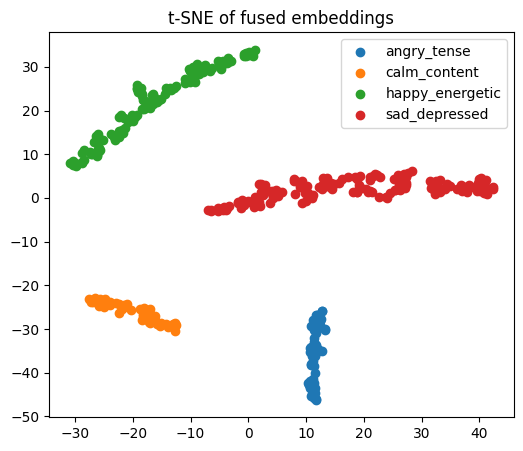

In [ ]:
from sklearn.manifold import TSNE

embs, genres = [], []
fusion_concat.eval()
with torch.no_grad():
    for t in test_set:
        text_emb = encode_text([t['caption']]).to(device)
        feats = torch.tensor(t['feats']).unsqueeze(0).to(device)
        adj = torch.tensor(t['adj']).unsqueeze(0).to(device)
        graph_emb = task2_model.embed(feats, adj)
        z = F.relu(fusion_concat.fc(torch.cat([text_emb, graph_emb], dim=1)))
        embs.append(z.cpu().numpy()[0])
        genres.append(t['genre'])
fusion_concat.train()

embs = np.stack(embs)
perplexity = min(15, max(1, len(embs) - 1))   # avoid crashing on small test sets
proj = TSNE(n_components=2, perplexity=perplexity, random_state=SEED).fit_transform(embs)

plt.figure(figsize=(6, 5))
for g in sorted(set(genres)):
    idx = [i for i, gg in enumerate(genres) if gg == g]
    plt.scatter(proj[idx, 0], proj[idx, 1], label=g)
plt.legend()
plt.title('t-SNE of fused embeddings')
plt.show()

#Task 4 (bonus): contrastive text-graph alignment


In [ ]:
def load_musiccaps_metadata(csv_path, n_tracks=None):

    df = pd.read_csv(csv_path)

    if n_tracks is not None:
        df = df.head(n_tracks)
    return df


def download_musiccaps_audio(ds, out_dir, sr=22050):
    import subprocess
    import os

    os.makedirs(out_dir, exist_ok=True)

    for _, row in ds.iterrows():

        out_path = os.path.join(out_dir, str(row['ytid']) + '.wav')

        if os.path.exists(out_path):
            continue

        url = 'https://www.youtube.com/watch?v=' + str(row['ytid'])

        cmd = [
            'yt-dlp',
            '-x',
            '--audio-format', 'wav',
            '--audio-quality', '0',
            '--postprocessor-args',
            'ffmpeg:-ss {} -to {}'.format(row['start_s'],row['end_s']),'-o',out_path,url]

        try:
            subprocess.run(cmd, check=True, timeout=60, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

        except Exception:
            continue

def load_musiccaps(audio_dir, ds, sr=22050, clip_duration=10.0):
    tracks = []

    for _, row in ds.iterrows():

        path = os.path.join(audio_dir, str(row['ytid']) + '.wav')

        if not os.path.exists(path):
            continue
        try:
            y, _ = librosa.load(path, sr=sr, duration=clip_duration)

        except Exception:
            continue
        feats = segment_chroma(y, sr)
        adj = build_adj_from_feats(feats)

        if row['aspect_list']:
            try:
                aspects = eval(row['aspect_list'])
                caption = ' '.join(aspects)
            except Exception:
                caption = str(row['caption'])
        else:
            caption = str(row['caption'])
        tracks.append({'feats': feats, 'adj': adj, 'caption': caption})

    return tracks


musiccaps_train, musiccaps_test = [], []

if USE_MUSICCAPS:
    mc_meta = load_musiccaps_metadata(MUSICCAPS_CSV, n_tracks=600)

    print(f'Metadata loaded: {len(mc_meta)} tracks')

    download_musiccaps_audio(mc_meta, MUSICCAPS_AUDIO_DIR)
    musiccaps_tracks = load_musiccaps(MUSICCAPS_AUDIO_DIR, mc_meta)
    random.shuffle(musiccaps_tracks)

    n_mc_train = int(0.8 * len(musiccaps_tracks))

    musiccaps_train = musiccaps_tracks[:n_mc_train]
    musiccaps_test = musiccaps_tracks[n_mc_train:]

    print(f'loaded {len(musiccaps_tracks)} MusicCaps tracks with audio for Task 4')

Metadata loaded: 600 tracks
loaded 0 MusicCaps tracks with audio for Task 4


#Results & Summary

model                    macro F1     AUC-PR
random baseline             ~0.05      ~0.15
flat MLP (no graph)         0.258      0.384
BERT only                   1.000      1.000
GNN only                    0.296      0.384
fusion (concat)             1.000      1.000
fusion (attention)          1.000      1.000
emotion (DEAM)         MAE 0.114  R2 0.107


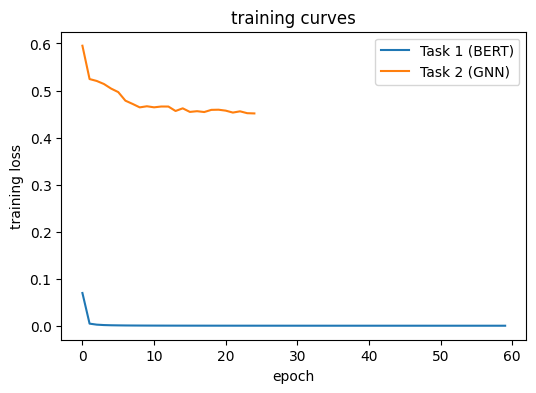

In [ ]:
print('%-22s %10s %10s' % ('model', 'macro F1', 'AUC-PR'))
print('%-22s %10s %10s' % ('random baseline', '~0.05', '~0.15'))
print('%-22s %10.3f %10.3f' % ('flat MLP (no graph)', macro_b, aucpr_b))
print('%-22s %10.3f %10.3f' % ('BERT only', macro_t1, aucpr_t1))
print('%-22s %10.3f %10.3f' % ('GNN only', macro_t2, aucpr_t2))
print('%-22s %10.3f %10.3f' % ('fusion (concat)', macro_concat, aucpr_concat))
print('%-22s %10.3f %10.3f' % ('fusion (attention)', macro_attn, aucpr_attn))
if emo_result is not None:
    print('%-22s MAE %.3f  R2 %.3f' % ('emotion (DEAM)', emo_result[0], emo_result[1]))

plt.figure(figsize=(6, 4))
plt.plot(loss_hist_t1, label='Task 1 (BERT)')
plt.plot(loss_hist_t2, label='Task 2 (GNN)')
plt.xlabel('epoch')
plt.ylabel('training loss')
plt.legend()
plt.title('training curves')
plt.show()